In [2]:
from google.colab import files

uploaded = files.upload()

Saving bank_transactions_data_2.csv to bank_transactions_data_2 (1).csv


# Banking Operations Intelligence Platform

## Business Problem

Retail banks process thousands of customer transactions every day through online banking, ATMs, and physical branches. Understanding customer transaction behavior, operational efficiency, and potential risk indicators is essential for improving customer experience and reducing operational risk.

This project analyzes banking transaction data to uncover customer behavior patterns, evaluate operational performance, and identify potential operational risk indicators using exploratory data analysis.

---

## Project Objectives

- Analyze customer transaction behavior
- Evaluate operational performance across banking channels
- Identify customer segments and transaction trends
- Detect potential operational risk indicators
- Generate actionable business recommendations

---

## Key Business Questions

1. Which banking channels are used most frequently?
2. What customer demographics drive transaction activity?
3. What are the peak transaction periods?
4. Which factors indicate operational risk?
5. What business recommendations can improve banking operations?

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [4]:
df = pd.read_csv("/content/bank_transactions_data_2.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,"5,112.21",2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,"13,758.91",2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,"1,122.35",2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,"8,569.06",2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,"7,429.40",2024-11-04 08:06:39


In [5]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()

Rows : 2512
Columns : 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14 

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,2512,2512,TX002496,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,2512,495,AC00460,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmount,"2,512.00",NaN,NaN,NaN,297.59,291.95,0.26,81.89,211.14,414.53,"1,919.11"
TransactionDate,2512,2512,2023-04-03 16:07:53,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionType,2512,2,Debit,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2512,43,Fort Worth,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceID,2512,681,D000548,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP Address,2512,592,200.136.146.93,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MerchantID,2512,100,M026,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2512,3,Branch,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
TransactionID,0,0.00
AccountID,0,0.00
TransactionAmount,0,0.00
TransactionDate,0,0.00
TransactionType,0,0.00
Location,0,0.00
DeviceID,0,0.00
IP Address,0,0.00
MerchantID,0,0.00
Channel,0,0.00


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.nunique().sort_values()

,0
TransactionType,2
Channel,3
CustomerOccupation,4
LoginAttempts,5
Location,43
CustomerAge,63
MerchantID,100
TransactionDuration,288
PreviousTransactionDate,360
AccountID,495


In [10]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [11]:
df["TransactionHour"] = df["TransactionDate"].dt.hour

df["Weekday"] = df["TransactionDate"].dt.day_name()

df["Month"] = df["TransactionDate"].dt.month_name()

df["TimeSinceLastTransaction"] = (
    df["TransactionDate"] -
    df["PreviousTransactionDate"]
).dt.total_seconds() / 3600

threshold = df["TransactionAmount"].quantile(0.95)

df["HighValueTransaction"] = np.where(
    df["TransactionAmount"] >= threshold,
    "Yes",
    "No"
)

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionHour,Weekday,Month,TimeSinceLastTransaction,HighValueTransaction
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,"5,112.21",2024-11-04 08:08:08,16,Tuesday,April,"-13,743.65",No
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,"13,758.91",2024-11-04 08:09:35,16,Tuesday,June,"-11,895.42",No
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,"1,122.35",2024-11-04 08:07:04,18,Monday,July,"-11,581.85",No
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,"8,569.06",2024-11-04 08:09:06,16,Friday,May,"-13,167.62",No
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,"7,429.40",2024-11-04 08:06:39,17,Monday,October,"-9,230.25",No


Executive Overview

In [12]:
print("="*50)
print("BANKING OPERATIONS SUMMARY")
print("="*50)

print(f"Total Transactions        : {len(df):,}")
print(f"Unique Customers          : {df['AccountID'].nunique():,}")
print(f"Total Transaction Value   : ${df['TransactionAmount'].sum():,.2f}")
print(f"Average Transaction Value : ${df['TransactionAmount'].mean():,.2f}")
print(f"Average Account Balance   : ${df['AccountBalance'].mean():,.2f}")

BANKING OPERATIONS SUMMARY
Total Transactions        : 2,512
Unique Customers          : 495
Total Transaction Value   : $747,555.57
Average Transaction Value : $297.59
Average Account Balance   : $5,114.30


Transaction Amount Distribution

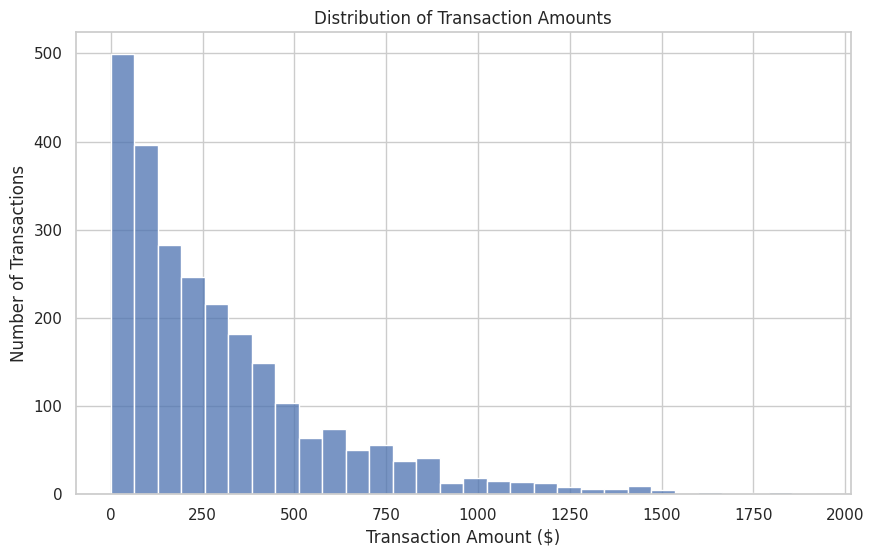

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="TransactionAmount",
    bins=30
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Number of Transactions")

plt.show()

### Business Insight

Most banking transactions fall within the lower transaction value range, while a small number of high-value transactions create a right-skewed distribution. These transactions may require additional monitoring depending on customer profiles and transaction context.

Transaction Type

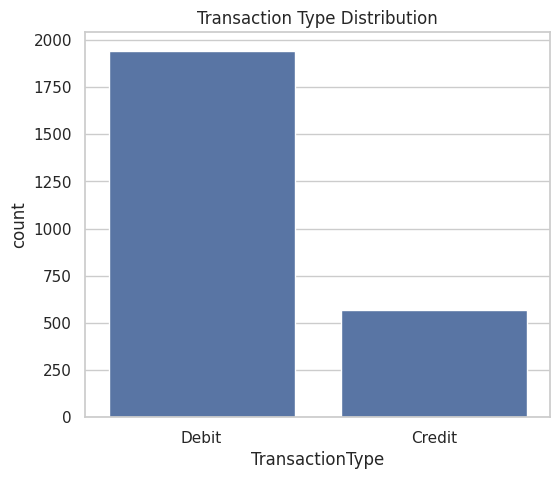

,count
TransactionType,
Debit,1944
Credit,568


In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="TransactionType"
)

plt.title("Transaction Type Distribution")

plt.show()

df["TransactionType"].value_counts()

### Business Insight

Understanding the proportion of debit and credit transactions helps evaluate customer spending and account usage behavior. Significant imbalance may indicate dominant transaction patterns across the customer base.

Banking Channel Usage

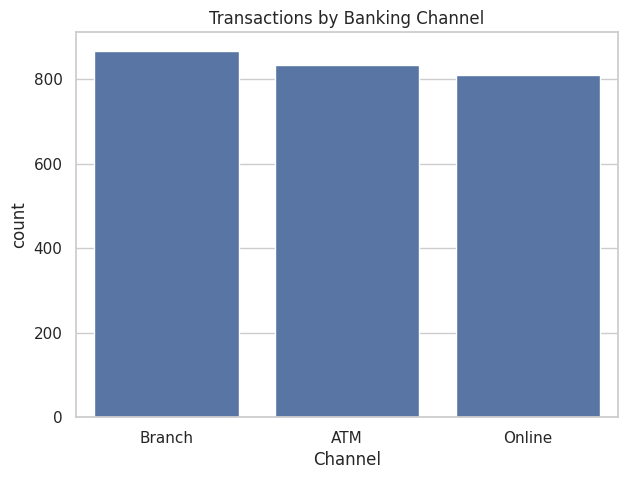

,count
Channel,
Branch,868
ATM,833
Online,811


In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Channel",
    order=df["Channel"].value_counts().index
)

plt.title("Transactions by Banking Channel")

plt.show()

df["Channel"].value_counts()

### Business Insight

Digital banking adoption can be assessed by comparing online transactions with ATM and branch usage. These insights support channel optimization and resource planning.

Customer Occupation

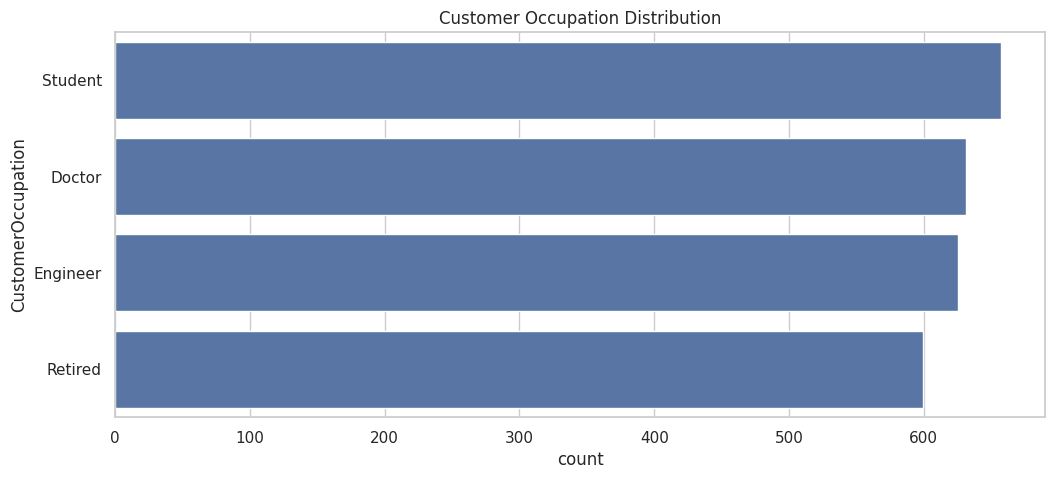

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="CustomerOccupation",
    order=df["CustomerOccupation"].value_counts().index
)

plt.title("Customer Occupation Distribution")

plt.show()

### Business Insight

Customer occupation provides insight into the composition of the customer base and supports segmentation strategies for targeted banking products and services.

Customer Age Distribution

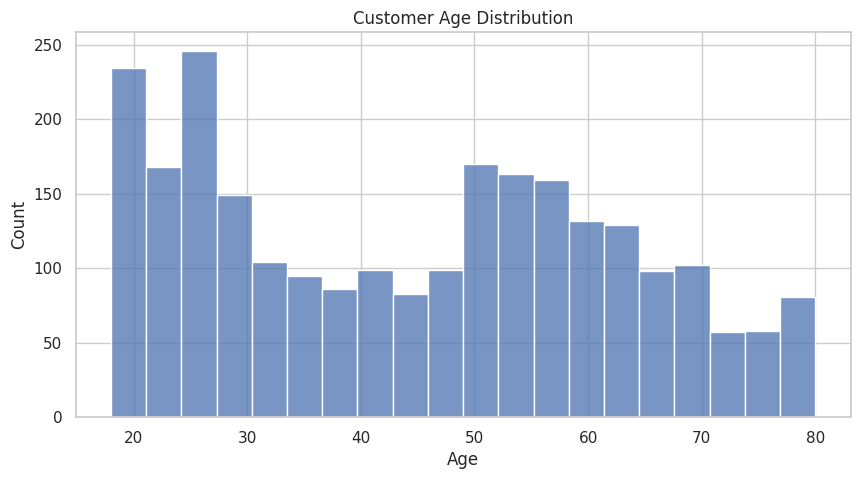

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="CustomerAge",
    bins=20
)

plt.title("Customer Age Distribution")

plt.xlabel("Age")

plt.show()

### Business Insight

Age distribution helps identify the bank's primary customer demographics and informs decisions around digital services, marketing, and customer engagement.

Top Transaction Locations

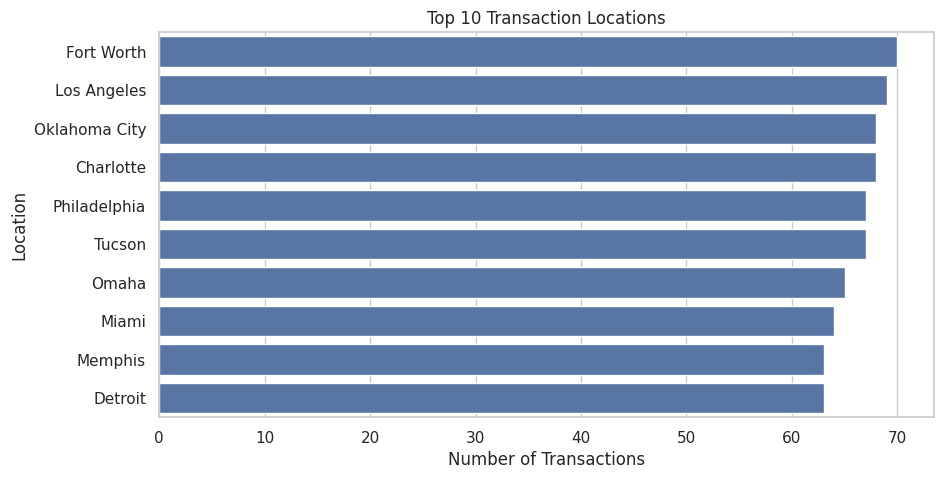

In [18]:
top_locations = df["Location"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 10 Transaction Locations")

plt.xlabel("Number of Transactions")

plt.show()

### Business Insight

High transaction volumes in certain locations may reflect customer concentration, branch activity, or regional preferences that can influence operational planning.

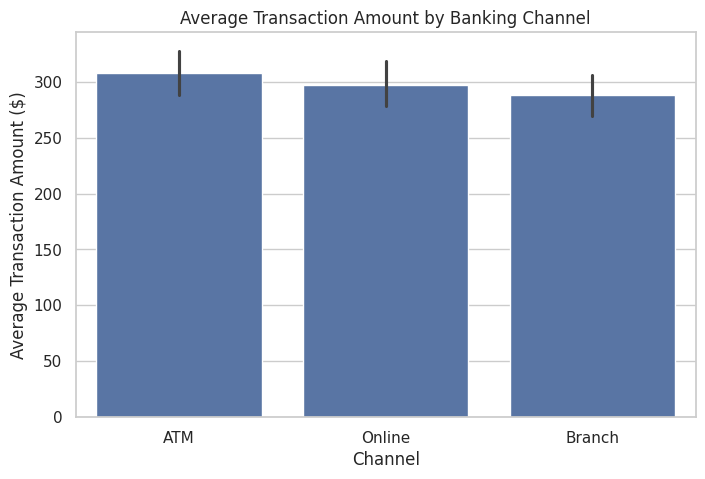

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Channel",
    y="TransactionAmount",
    estimator="mean"
)

plt.title("Average Transaction Amount by Banking Channel")

plt.ylabel("Average Transaction Amount ($)")

plt.show()

### Business Insight

Comparing average transaction values across banking channels provides insight into how customers use different services and where higher-value transactions typically occur.

Peak Banking Hours

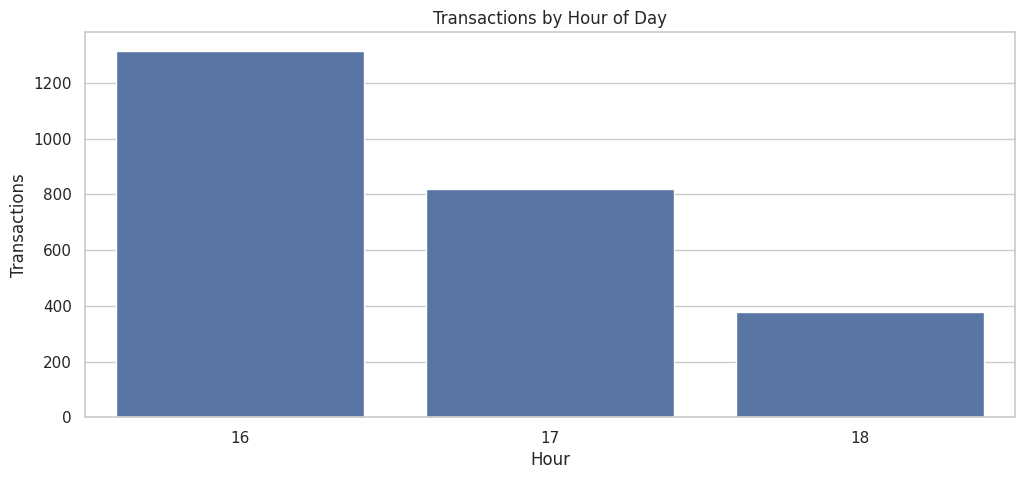

In [20]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="TransactionHour"
)

plt.title("Transactions by Hour of Day")

plt.xlabel("Hour")

plt.ylabel("Transactions")

plt.show()

Business & Risk Analytics

Average Transaction Amount by Occupation

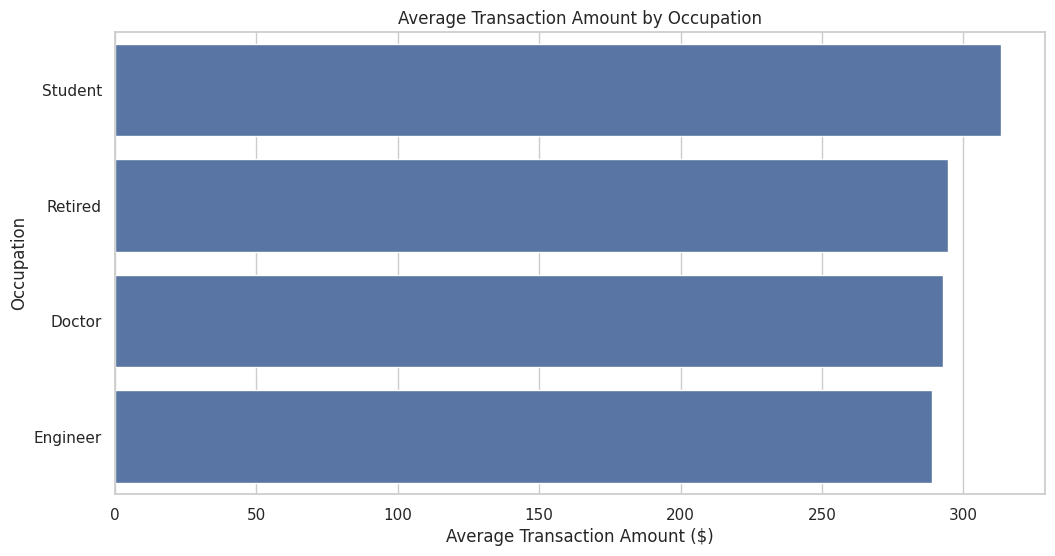

In [21]:
plt.figure(figsize=(12,6))

occupation_avg = (
    df.groupby("CustomerOccupation")["TransactionAmount"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=occupation_avg.values,
    y=occupation_avg.index
)

plt.title("Average Transaction Amount by Occupation")
plt.xlabel("Average Transaction Amount ($)")
plt.ylabel("Occupation")

plt.show()

Customers from different occupations exhibit varying spending behavior. Understanding these differences helps financial institutions design personalized banking products and targeted marketing strategies.

Account Balance Distribution

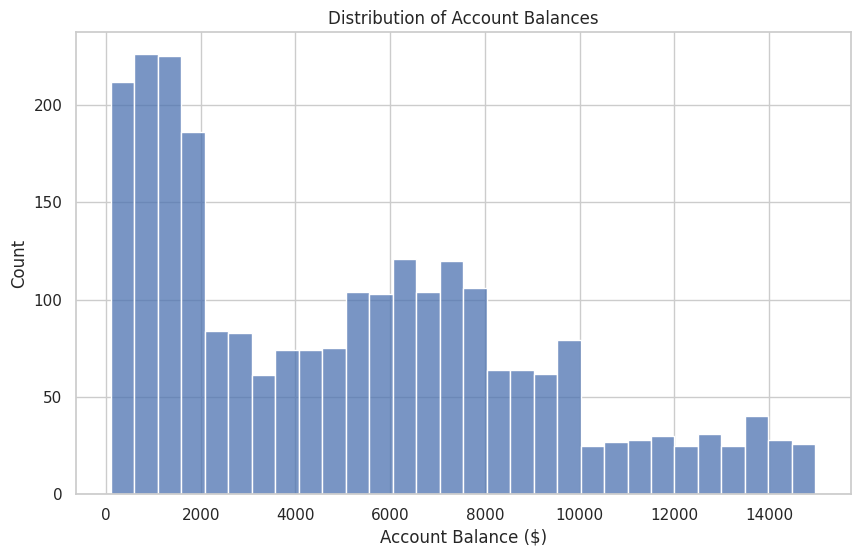

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["AccountBalance"],
    bins=30
)

plt.title("Distribution of Account Balances")

plt.xlabel("Account Balance ($)")

plt.show()

Login Attempts

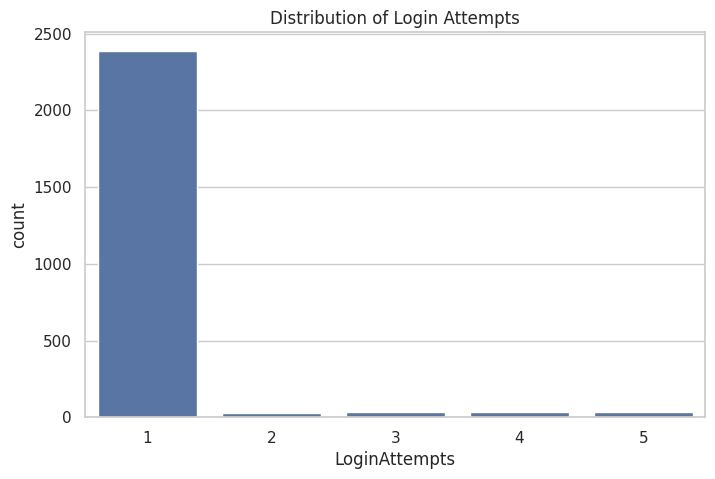

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="LoginAttempts"
)

plt.title("Distribution of Login Attempts")

plt.show()

Most customers successfully authenticate within one or two attempts. Transactions involving multiple login attempts may warrant additional monitoring for operational or security purposes.

High Value Transactions

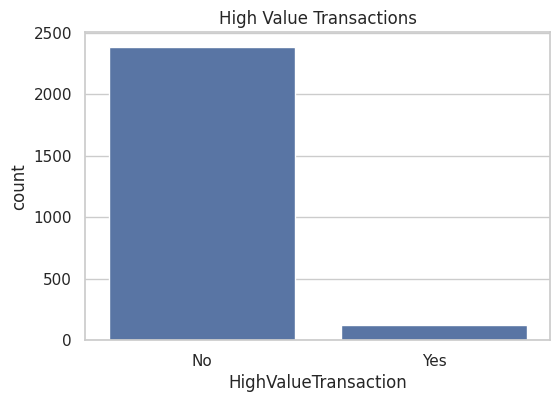

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="HighValueTransaction"
)

plt.title("High Value Transactions")

plt.show()

Transaction Duration

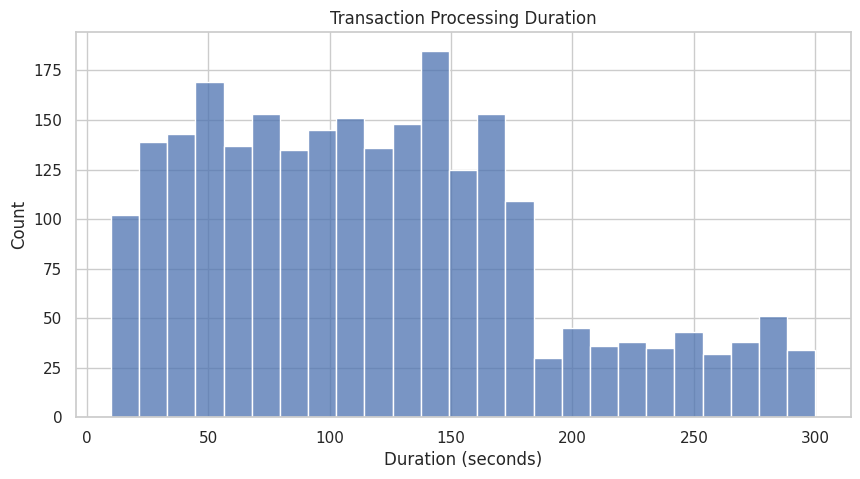

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="TransactionDuration",
    bins=25
)

plt.title("Transaction Processing Duration")

plt.xlabel("Duration (seconds)")

plt.show()

Average Duration by Channel

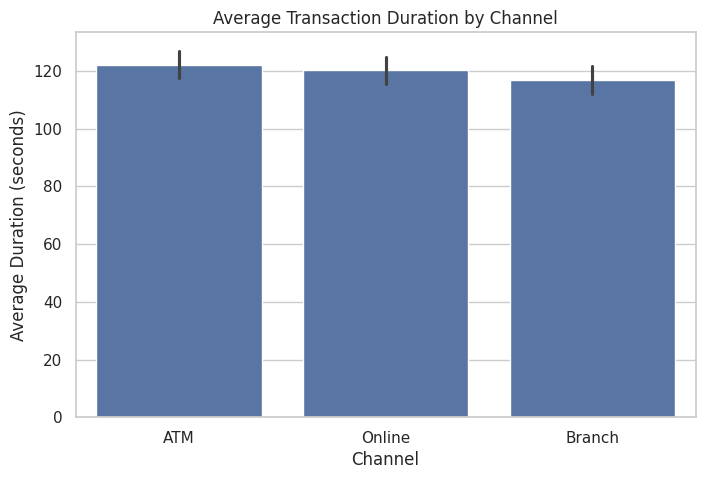

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Channel",
    y="TransactionDuration",
    estimator="mean"
)

plt.title("Average Transaction Duration by Channel")

plt.ylabel("Average Duration (seconds)")

plt.show()

High Value Transactions by Channel

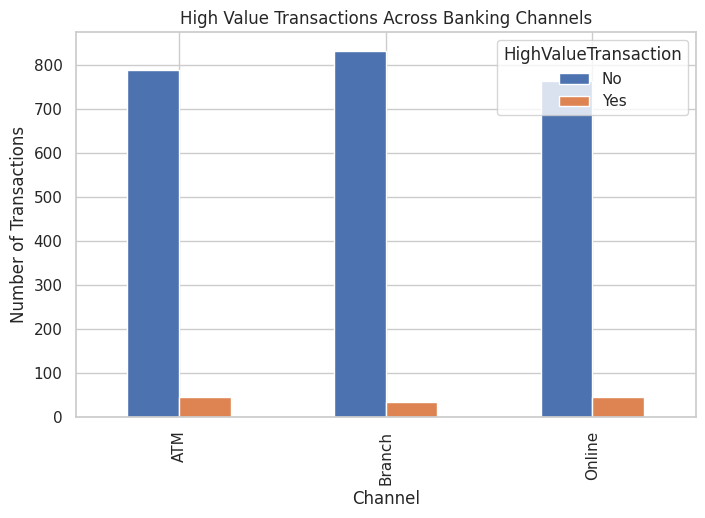

In [27]:
high_value = pd.crosstab(
    df["Channel"],
    df["HighValueTransaction"]
)

high_value.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("High Value Transactions Across Banking Channels")

plt.ylabel("Number of Transactions")

plt.show()

Correlation Heatmap

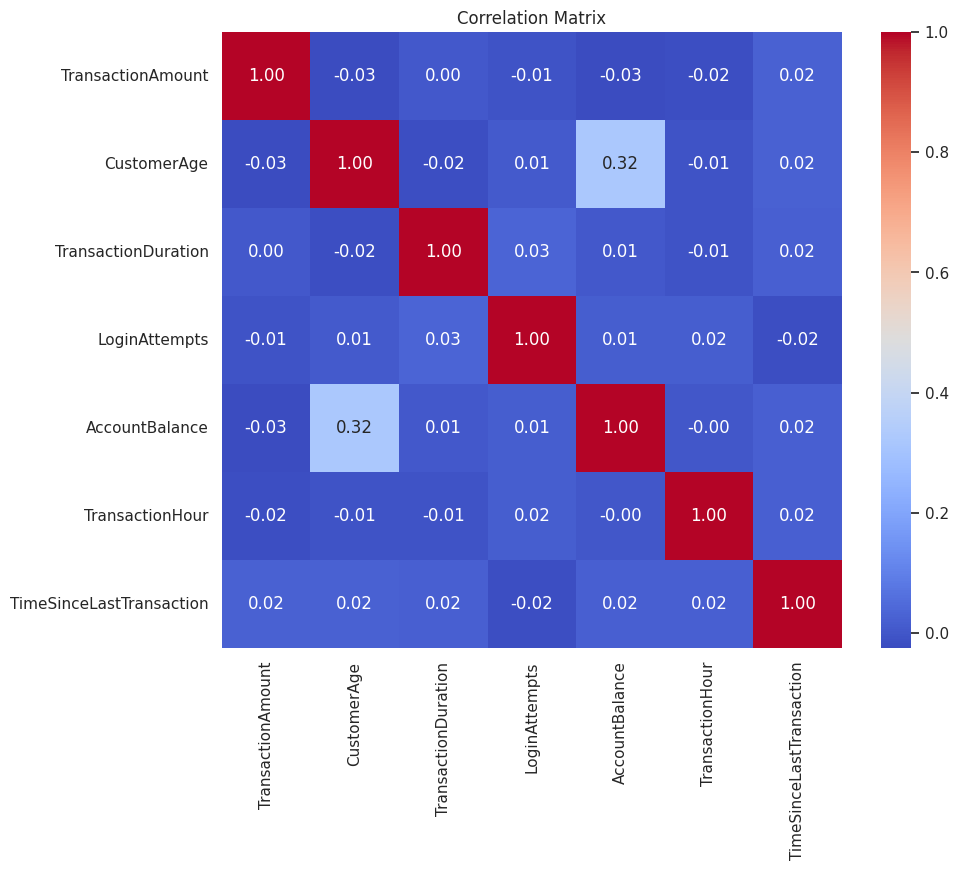

In [28]:
plt.figure(figsize=(10,8))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Executive Summary

## Key Findings

- Most transactions are concentrated within lower transaction values, with a limited number of high-value transactions.

- Online banking remains a frequently used transaction channel, highlighting continued digital adoption.

- Customer transaction behavior varies across occupational groups, indicating opportunities for personalized financial services.

- A small proportion of transactions involve multiple login attempts, representing potential operational risk indicators.

- Transaction duration differs across banking channels, providing opportunities for operational efficiency improvements.

---

## Recommendations

1. Monitor transactions involving repeated login attempts.

2. Continue investing in digital banking capabilities.

3. Develop customer segmentation strategies using demographic insights.

4. Monitor high-value transactions through additional risk controls.

5. Build executive dashboards for continuous operational monitoring.